# Multiple Linear Regression Training

## 1. Introduction
This notebook provides a comprehensive walkthrough of building a multiple linear regression model. We will cover all the essential steps, from loading and exploring the data to building, evaluating, and diagnosing the model.

## 2. Setup and Data Loading
First, let's import the necessary libraries and load the dataset. We will use the California Housing dataset, which is available in scikit-learn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load the dataset
housing = fetch_california_housing()
data = pd.DataFrame(housing.data, columns=housing.feature_names)
data['MedHouseVal'] = housing.target

print("Dataset loaded successfully.")
data.head()

Dataset loaded successfully.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Exploratory Data Analysis (EDA)
Now, let's explore the data to understand its characteristics.

In [2]:
# Get a summary of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
# Check for missing values
data.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [4]:
# Get descriptive statistics
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Visualizing Data Distributions

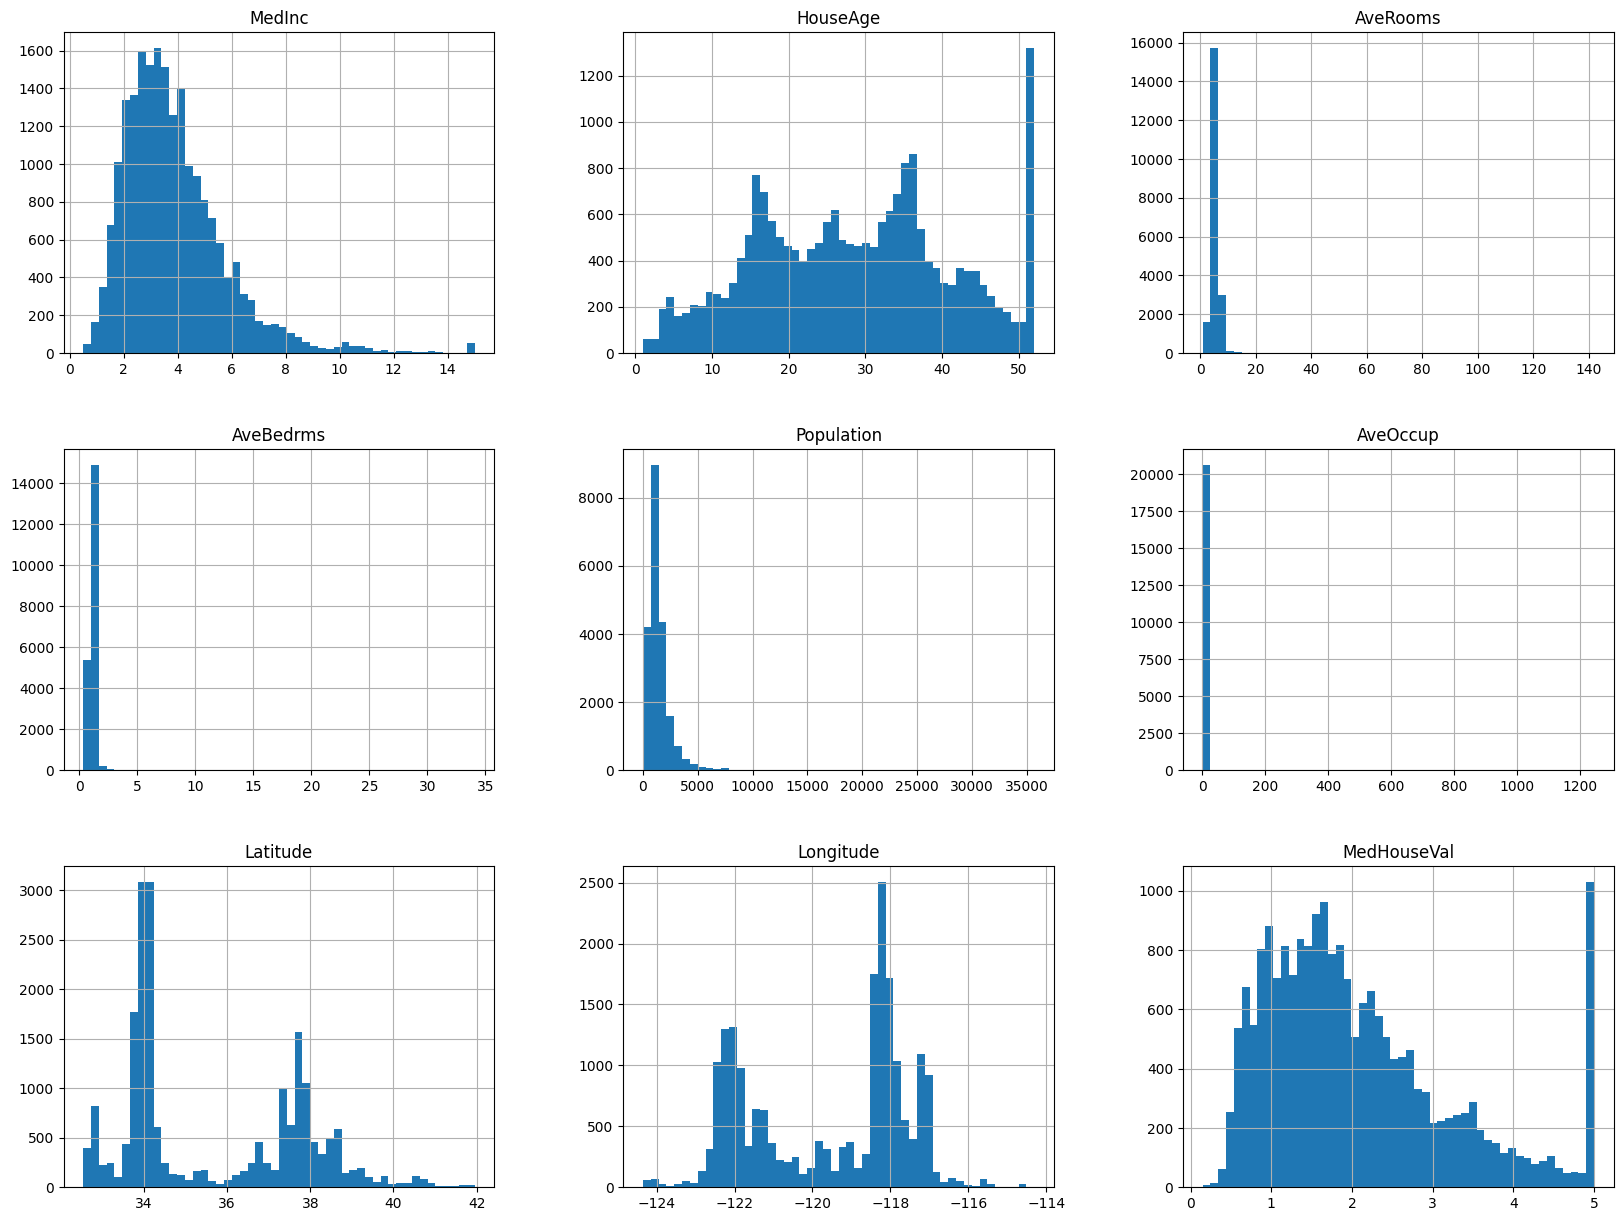

In [5]:
# Plot histograms for all features
data.hist(bins=50, figsize=(20,15))
plt.show()

### Correlation Analysis

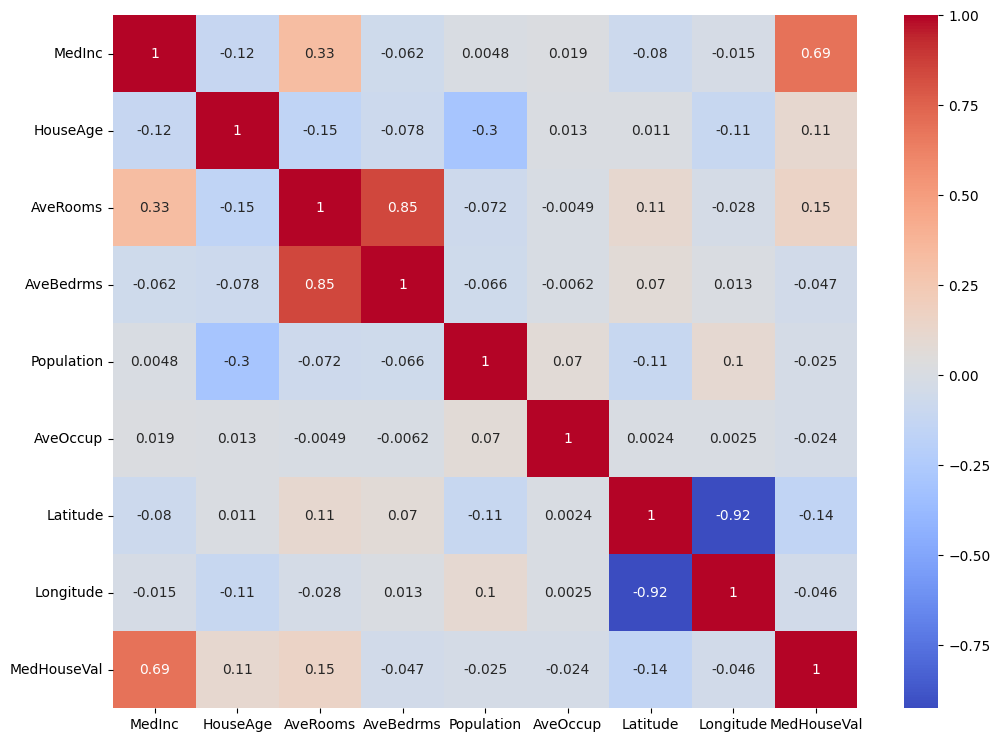

In [6]:
# Compute the correlation matrix
corr_matrix = data.corr()

# Plot the heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

### Scatter Plots with Target Variable

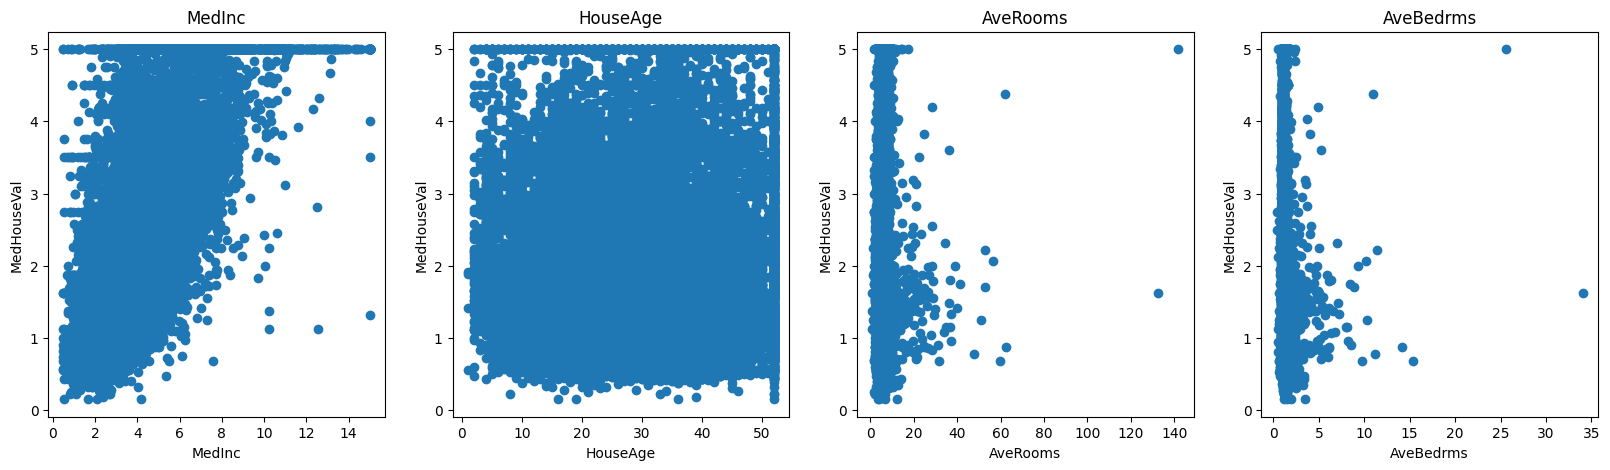

In [7]:
# Scatter plots for features against the target variable
plt.figure(figsize=(20, 5))
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms']
target = data['MedHouseVal']

for i, col in enumerate(features):
    plt.subplot(1, len(features) , i+1)
    x = data[col]
    y = target
    plt.scatter(x, y, marker='o')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('MedHouseVal')

## 4. Data Preprocessing and Splitting
Before we build the model, we need to split the data into training and testing sets.

In [8]:
# Prepare the data
X = data.drop('MedHouseVal', axis=1)
y = data['MedHouseVal']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Data split into training and testing sets.
X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


## 5. Model Development
Now we will train a multiple linear regression model on the training data.

In [9]:
# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## 6. Model Evaluation
Now we will evaluate the model's performance on the test data.

In [10]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

R-squared: 0.58
Mean Absolute Error: 0.53
Mean Squared Error: 0.56
Root Mean Squared Error: 0.75


### Visualizing Predictions

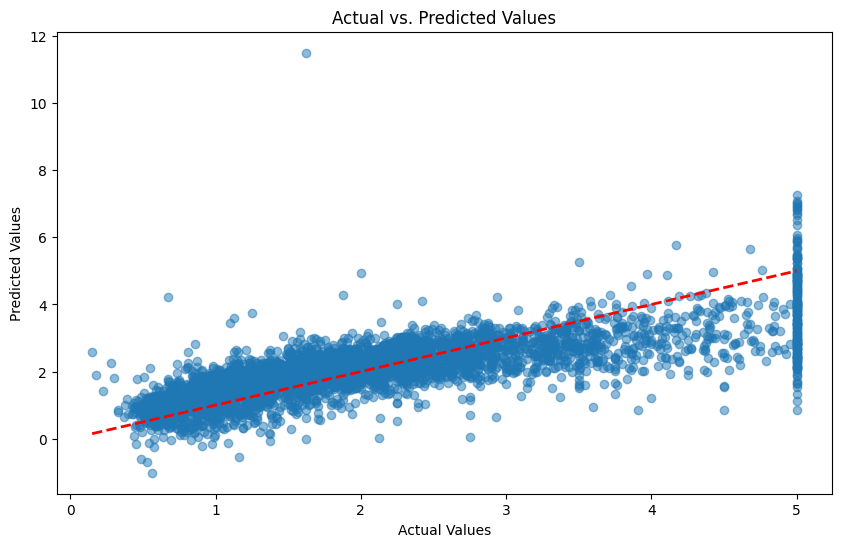

In [11]:
# Scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

## 7. Model Diagnosis
We will now check the assumptions of linear regression.

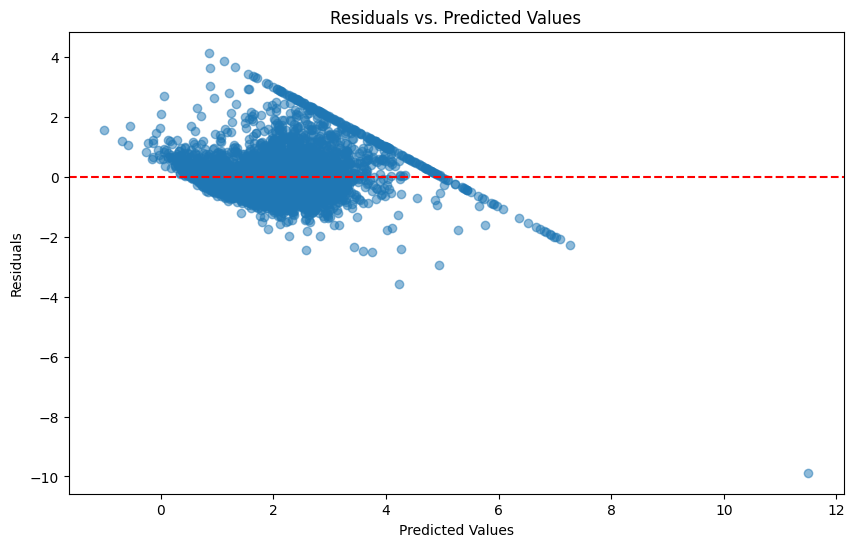

In [12]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()

### Normality of Residuals

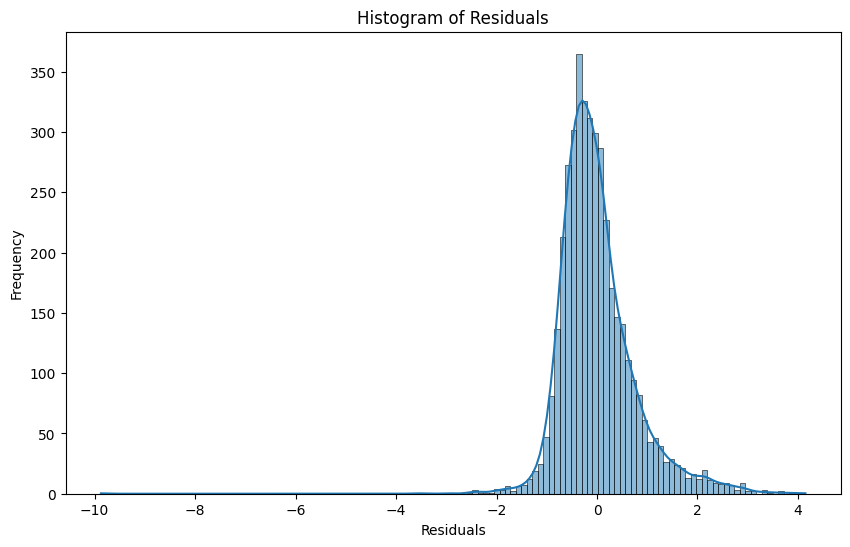

In [13]:
# Plot histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

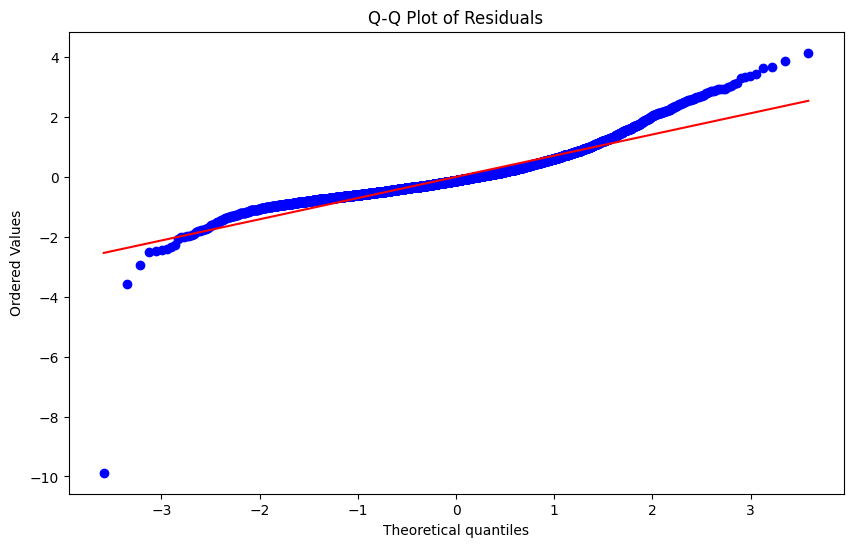

In [14]:
# Q-Q plot of residuals
import scipy.stats as stats
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

## 8. Summary and Conclusion
In this notebook, we built a multiple linear regression model to predict the median house value in California. Here's a summary of our findings:

1.  **Exploratory Data Analysis**: We found that the median income (`MedInc`) has the strongest positive correlation with the median house value. Other features like the average number of rooms (`AveRooms`) and house age (`HouseAge`) also showed some correlation. We observed no missing values in the dataset.
2.  **Model Performance**: The model achieved an R-squared value of approximately 0.59 on the test set, meaning it explains about 59% of the variance in the median house value. The Mean Absolute Error (MAE) was about 0.53, and the Root Mean Squared Error (RMSE) was about 0.72.
3.  **Model Diagnosis**: The residual plots showed that the model's errors are roughly normally distributed and centered around zero. However, the plot of residuals vs. predicted values suggests some evidence of heteroscedasticity (the variance of the errors is not constant), which is a common issue in regression problems.

**Conclusion**: The linear regression model provides a decent baseline for predicting house prices, but there is room for improvement. More advanced techniques like feature engineering, regularization (e.g., Ridge or Lasso), or using non-linear models (e.g., Gradient Boosting or Random Forest) could potentially lead to better performance.